# **1. Perkenalan Dataset**

## 1. Sumber dan Deskripsi Dataset

Dataset yang digunakan dalam proyek ini adalah **Student Performance Analytics Dataset** yang diperoleh dari platform Kaggle dengan detail sebagai berikut:

* **Nama Dataset**: Student Performance Analytics Dataset
* **Sumber**: Kaggle
* **Pemilik Dataset**: borovai0
* **Link Dataset**:
  https://www.kaggle.com/datasets/borovai0/student-performance-analytics-dataset

Dataset diunduh menggunakan library `kagglehub` dengan kode berikut:

```python
import kagglehub

path = kagglehub.dataset_download(
    "borovai0/student-performance-analytics-dataset"
)

print("Path to dataset files:", path)
```

Dataset ini berisi lebih dari **10.000 data siswa** dengan berbagai atribut yang berkaitan dengan performa akademik, kebiasaan belajar, keterlibatan siswa dalam pembelajaran, serta faktor pendukung dari lingkungan belajar siswa.

Setiap baris data merepresentasikan satu individu siswa dengan sejumlah fitur yang dapat dikelompokkan menjadi beberapa kategori utama berikut:

### a. Academic Performance

Fitur yang menggambarkan performa akademik siswa, seperti:

* assignment_score
* midterm_score
* final_exam_score
* participation_score

### b. Study Behavior

Fitur yang menggambarkan kebiasaan belajar siswa, seperti:

* study_hours_per_day
* sleep_hours

### c. Engagement

Fitur yang menggambarkan keterlibatan siswa dalam aktivitas pembelajaran, seperti:

* attendance_percentage
* participation_score

### d. Background Factors

Fitur yang menggambarkan kondisi pendukung pembelajaran siswa, seperti:

* parent_education
* internet_access
* extra_classes
* gender

Dataset ini menyediakan dua kemungkinan target untuk machine learning:

1. **Overall Score**
   Target numerik yang dapat digunakan untuk tugas regresi.

2. **Grade (A–F)**
   Target kategorikal yang dapat digunakan untuk tugas klasifikasi.

Pada proyek ini, target yang digunakan adalah **Grade** sehingga permasalahan machine learning yang dibangun termasuk ke dalam **supervised classification problem**.

---

## 2. Tujuan Penggunaan Dataset

Dataset ini digunakan untuk membangun model machine learning yang bertujuan untuk memprediksi kategori performa akademik siswa berdasarkan berbagai faktor akademik dan non-akademik.

Tujuan utama dari penggunaan dataset ini adalah:

1. Mengembangkan model klasifikasi untuk memprediksi grade siswa.
2. Menganalisis pengaruh fitur-fitur akademik terhadap performa siswa.
3. Membangun pipeline machine learning yang terintegrasi dengan konsep MLOps.
4. Mendokumentasikan proses eksperimen menggunakan MLflow.
5. Mengimplementasikan monitoring dan observability pada model inference.

Pemilihan dataset ini didasarkan pada beberapa pertimbangan berikut:

* Dataset memiliki jumlah data yang cukup besar untuk eksperimen machine learning.
* Dataset memiliki kombinasi fitur numerik dan kategorikal yang representatif.
* Struktur dataset relatif bersih dan minim missing values.
* Dataset sesuai untuk implementasi klasifikasi multi-class.
* Dataset cocok untuk pengembangan end-to-end MLOps pipeline.

Dengan karakteristik tersebut, dataset ini dinilai cukup representatif untuk membangun sistem machine learning berbasis klasifikasi performa akademik siswa.


# **2. Import Library**

## 2. Import Library

Pada tahap ini dilakukan proses impor pustaka Python yang diperlukan untuk mendukung seluruh pipeline machine learning, mulai dari pengolahan data, pemodelan, hingga pencatatan eksperimen menggunakan MLflow.

Library yang digunakan meliputi:

* **pandas** → digunakan untuk manipulasi dan analisis data berbasis tabel
* **numpy** → digunakan untuk operasi numerik dan pembuatan range parameter
* **scikit-learn** → digunakan untuk proses pemodelan, pembagian data (train-test split), serta evaluasi model
* **mlflow** → digunakan untuk melakukan tracking eksperimen, pencatatan parameter, metrik, dan model

Berikut adalah library yang diimpor:



Import library ini menjadi fondasi dalam membangun pipeline machine learning yang terstruktur dan dapat direproduksi, terutama dalam konteks penerapan MLOps.


In [31]:
# Manipulasi Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
import seaborn as sns
import os

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Save Model
import pickle
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini dilakukan proses pemuatan dataset ke dalam notebook menggunakan pustaka pandas. Dataset yang digunakan sebelumnya telah diunduh dari Kaggle menggunakan library kagglehub, kemudian file dataset dibaca ke dalam bentuk DataFrame agar dapat dianalisis dan diproses lebih lanjut.

Proses ini penting untuk memastikan bahwa:

dataset berhasil dimuat tanpa error,
struktur data sesuai,
nama kolom terbaca dengan benar,
tipe data dapat dikenali,
dan dataset siap digunakan untuk tahap eksplorasi maupun preprocessin

In [2]:
df = pd.read_csv('../data/student_performance_data.csv')

In [3]:
# menampilkan semua kolom
pd.set_option('display.max_columns', None)
# melihat sample data
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [4]:
# melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset sebelum masuk ke tahap preprocessing dan pemodelan machine learning.

EDA merupakan proses eksplorasi awal terhadap data yang bertujuan untuk memperoleh wawasan mengenai:

* distribusi data,
* hubungan antar fitur,
* pola tertentu dalam dataset,
* potensi outlier,
* ketidakseimbangan data,
* serta kualitas data secara keseluruhan.

Tahap ini sangat penting karena hasil analisis eksploratif akan membantu menentukan strategi preprocessing dan pendekatan pemodelan yang paling sesuai.

Beberapa analisis yang dilakukan pada tahap EDA meliputi:


In [5]:
# melihat missing value
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [6]:
# melihat duplikat data
df.duplicated().sum()

np.int64(0)

In [7]:
# statistik deskriptif
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [8]:
# melihat nilai untuk kolom gender
df['gender'].value_counts()

gender
Male      5013
Female    4987
Name: count, dtype: int64

In [9]:
# melihat nilai untuk kolom internet_access
df['internet_access'].value_counts()

internet_access
Yes    5061
No     4939
Name: count, dtype: int64

In [10]:
# melihat nilai untuk kolom extra_classes
df['extra_classes'].value_counts()

extra_classes
Yes    5087
No     4913
Name: count, dtype: int64

In [11]:
# melihat nilai untuk kolom parent_education
df['parent_education'].value_counts()

parent_education
High School    2528
Bachelor       2527
Master         2487
PhD            2458
Name: count, dtype: int64

In [12]:
# melihat nilai untuk kolom grade
df['grade'].value_counts()  

grade
C    5073
B    2704
D    2008
A     154
F      61
Name: count, dtype: int64

### Visualisasi

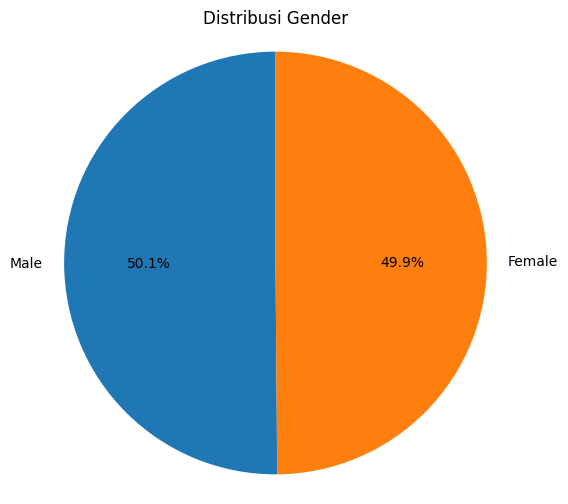

In [13]:
gender_counts = df["gender"].value_counts()

# plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribusi Gender")
plt.axis('equal') 
plt.show()

In [14]:
df["study_hours_category"] = pd.cut(
    df["study_hours_per_day"],
    bins=[1, 3, 5, 7, 9, 10],
    labels=["very_low", "low", "medium", "high", "very_high"],
    include_lowest=True
)

In [15]:
df["study_hours_category"].value_counts()

study_hours_category
very_low     2261
low          2252
medium       2223
high         2170
very_high    1094
Name: count, dtype: int64

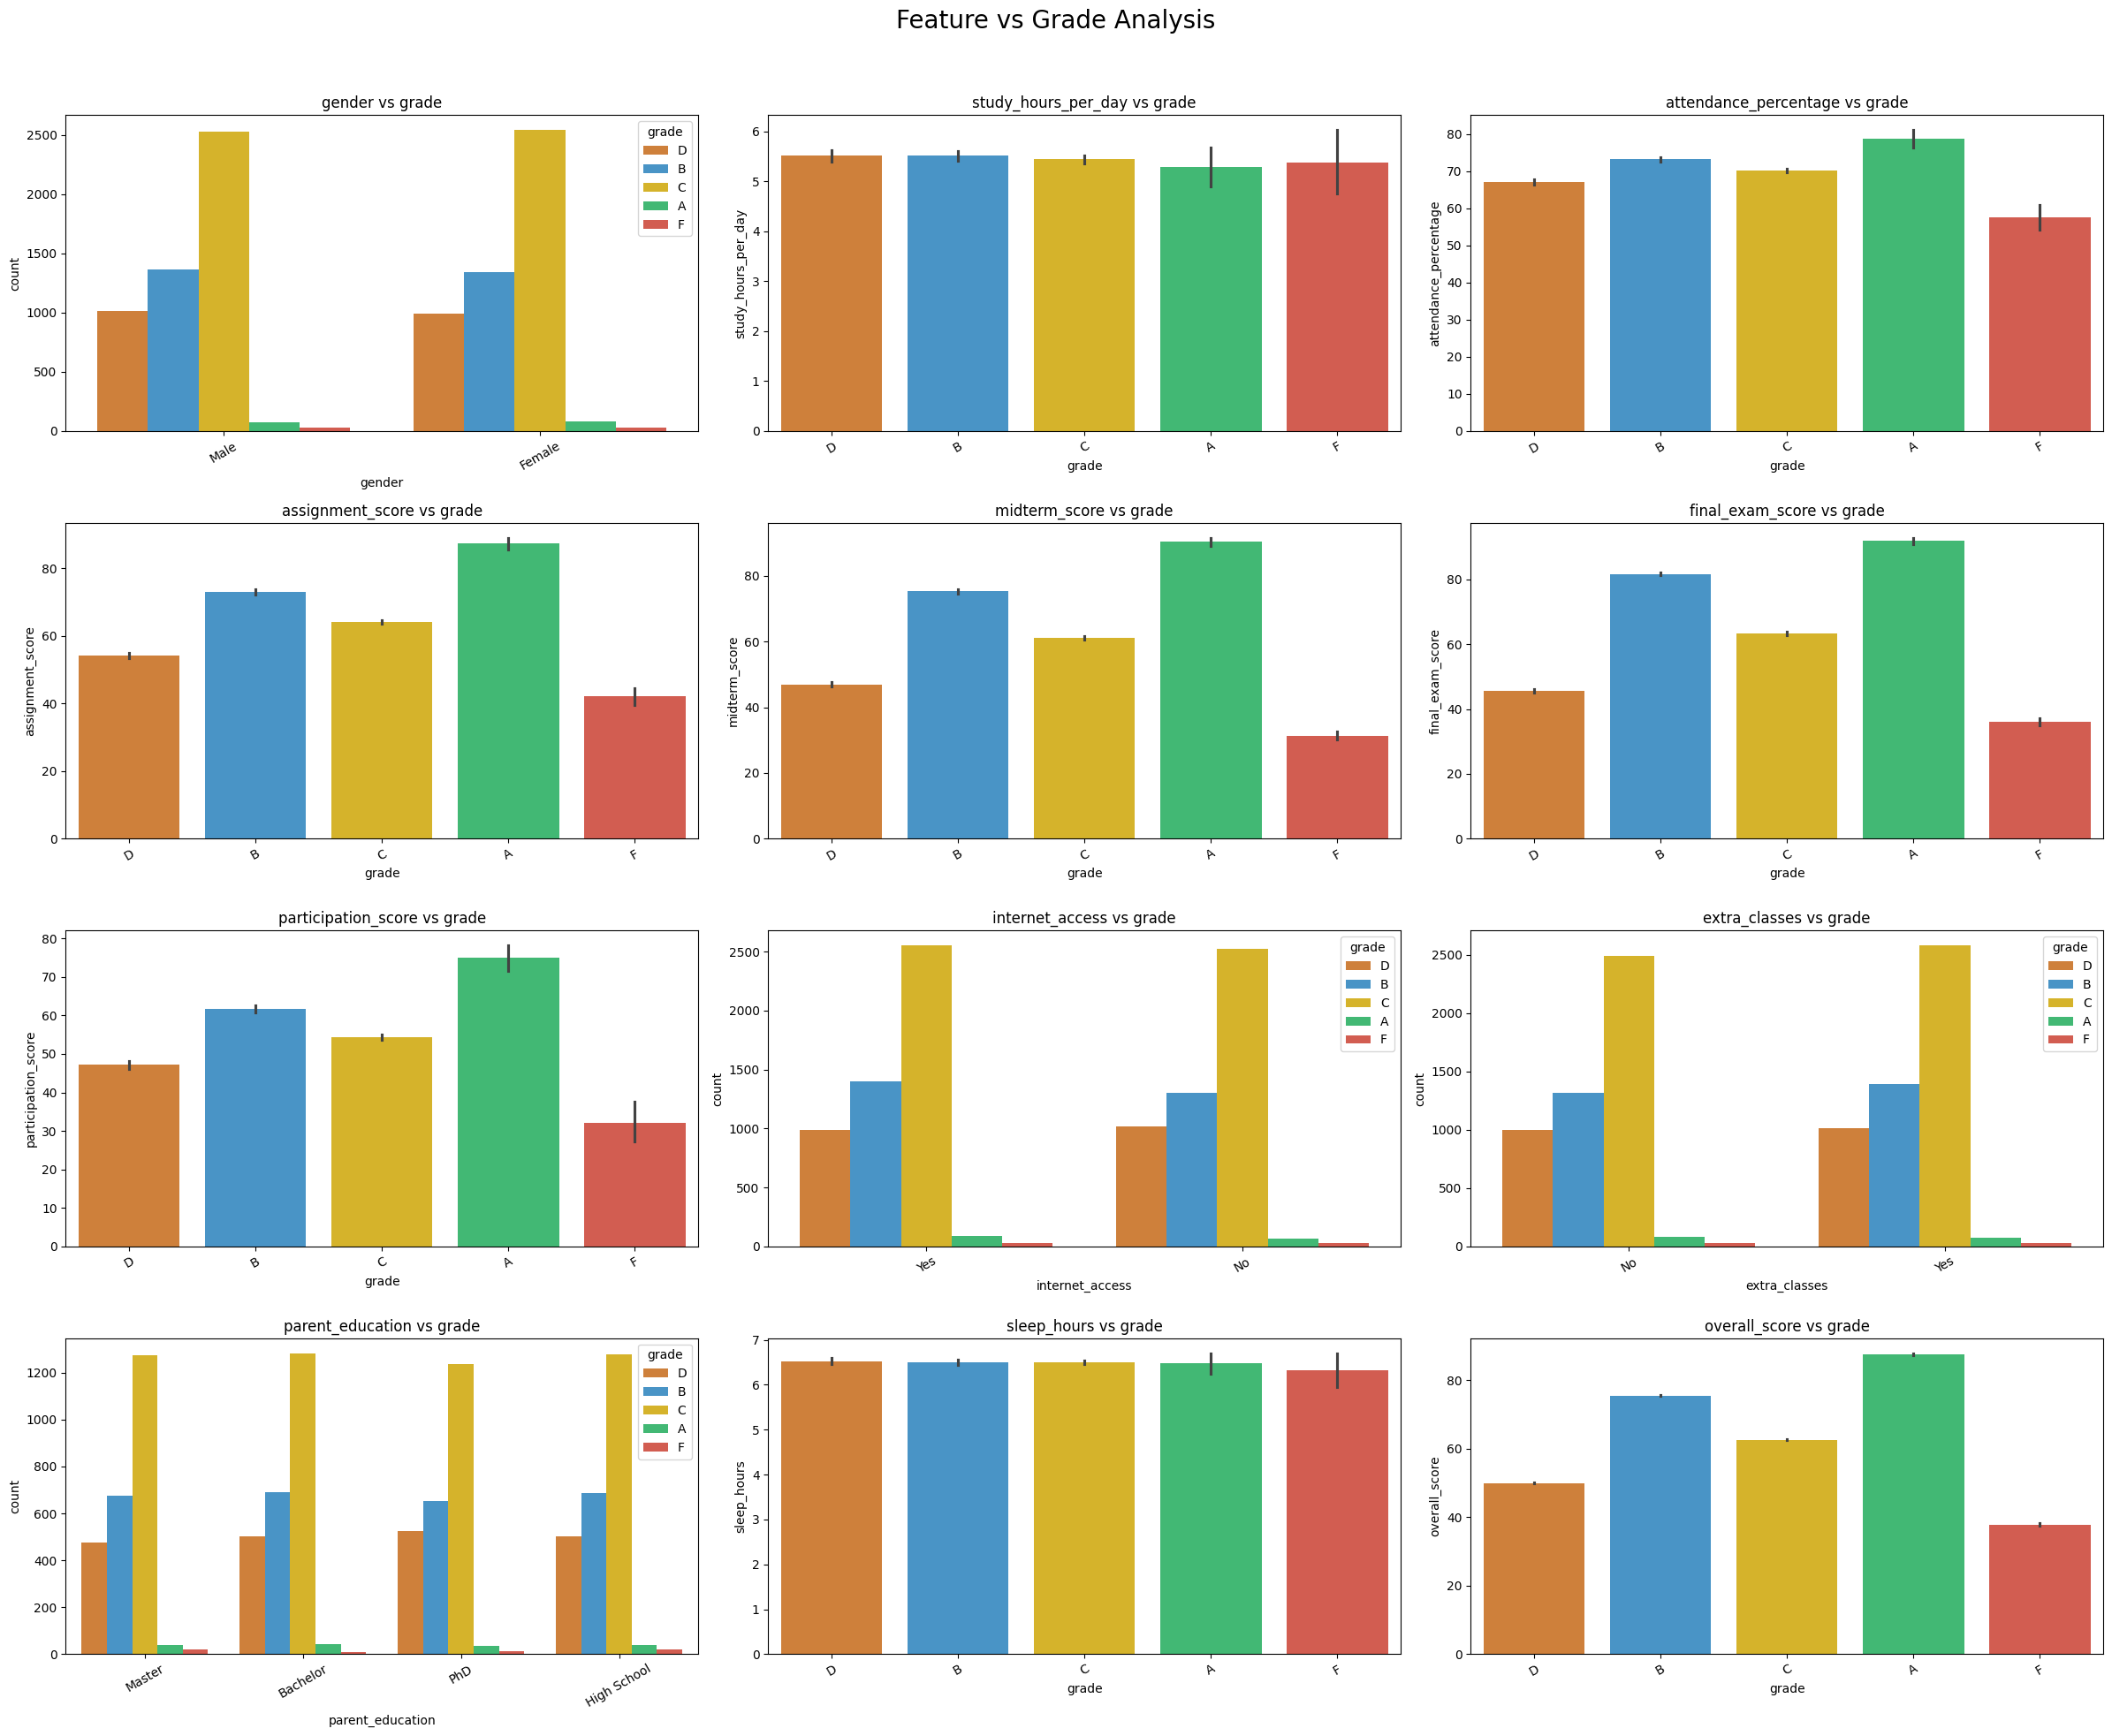

In [16]:

palette_grade = {
    "A": "#2ecc71",
    "B": "#3498db",
    "C": "#f1c40f",
    "D": "#e67e22",
    "F": "#e74c3c"
}

fig, axes = plt.subplots(4, 3, figsize=(24, 20))
fig.suptitle('Feature vs Grade Analysis', fontsize=20)

features = [
    'gender',
    'study_hours_per_day',
    'attendance_percentage',
    'assignment_score',
    'midterm_score',
    'final_exam_score',
    'participation_score',
    'internet_access',
    'extra_classes',
    'parent_education',
    'sleep_hours',
    'overall_score'
]

for ax, col in zip(axes.flatten(), features):

    if df[col].dtype == "object":
        sns.countplot(data=df, x=col, hue='grade', palette=palette_grade, ax=ax)
    else:
        sns.barplot(data=df, x='grade', y=col, palette=palette_grade, ax=ax)

    ax.set_title(f"{col} vs grade")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# **5. Data Preprocessing**

Pada tahap ini dilakukan proses **data preprocessing** untuk mempersiapkan dataset sebelum digunakan dalam proses machine learning.

Data preprocessing merupakan tahapan penting karena kualitas data sangat memengaruhi performa model yang akan dibangun. Dataset mentah umumnya masih memiliki berbagai permasalahan seperti:

* missing values,
* data duplikat,
* distribusi fitur yang tidak konsisten,
* data kategorikal yang belum dapat diproses model,
* serta ketidakseimbangan distribusi kelas.

Oleh karena itu, preprocessing dilakukan untuk memastikan bahwa dataset berada dalam kondisi optimal sebelum masuk ke tahap training model.

Pada proyek ini, preprocessing dilakukan menggunakan pendekatan terstruktur yang meliputi beberapa tahapan berikut.



In [17]:
df = df.drop(columns=["overall_score", "student_id"])

In [18]:
numeric = df.select_dtypes(include=["int64", "float64"]).columns
categoric = df.select_dtypes(include=["object"]).columns
# melihat nilai untuk tiap kategori baik numerik maupun kategorik

print("jumlah kolom numerik", len(numeric))
print("jumlah kolom kategorik", len(categoric))

jumlah kolom numerik 7
jumlah kolom kategorik 5


In [19]:
print(f'Jumlah baris: {len(df)}')

outlier = []
low_lim = []
high_lim = []

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    low_limit = Q1 - 1.5 * IQR
    high_limit = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < low_limit) | (df[col] > high_limit)).sum()

    outlier.append(outlier_count)
    low_lim.append(low_limit)
    high_lim.append(high_limit)

result = pd.DataFrame({
    "Column": numeric,
    "Lower Limit": low_lim,
    "Upper Limit": high_lim,
    "Outlier Count": outlier
})

result

Jumlah baris: 10000


,Column,Lower Limit,Upper Limit,Outlier Count
0,study_hours_per_day,-3.56000,14.52000,0
1,attendance_percentage,11.30000,129.54000,0
2,assignment_score,-4.34000,133.42000,0
3,midterm_score,-13.05375,137.79625,0
4,final_exam_score,-5.25000,135.15000,0
5,participation_score,-34.25250,144.96750,0
6,sleep_hours,1.36125,11.65125,0


In [20]:
mask = np.zeros(len(df), dtype=bool)

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    mask |= (df[col] < low) | (df[col] > high)

print("Total baris mengandung outlier:", mask.sum())

Total baris mengandung outlier: 0


In [21]:
# Cek Outlier
print(f'Jumlah baris: {len(df)}')

outlier = []
no_outlier = []
is_outlier = []
low_lim = []
high_lim = []

filtered_entries = np.array([True] * len(df))
for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low_limit = Q1 - (IQR * 1.5)
    high_limit = Q3 + (IQR * 1.5)

    # mulai filter outlier
    filter_outlier = ((df[col] >= low_limit) & (df[col] <= high_limit))
    outlier.append(len(df[~filter_outlier]))
    no_outlier.append(len(df[filter_outlier]))
    is_outlier.append(df[col][~filter_outlier].any())
    low_lim.append(low_limit)
    high_lim.append(high_limit)

    filtered_entries = ((df[col] >= low_limit) & (df[col] <= high_limit)) & filtered_entries

print("Outlier All Data :", len(df[~filtered_entries]))
print("Not Outlier All Data :", len(df[filtered_entries]))
print()

# Pastikan numeric diubah ke list jika masih berupa Index
pd.DataFrame({
    "Column Name": list(numeric),
    "is Outlier": is_outlier,
    "Lower Limit": low_lim,
    "Upper Limit": high_lim,
    "Outlier": outlier,
    "No Outlier": no_outlier
})

Jumlah baris: 10000
Outlier All Data : 0
Not Outlier All Data : 10000



,Column Name,is Outlier,Lower Limit,Upper Limit,Outlier,No Outlier
0,study_hours_per_day,False,-3.56000,14.52000,0,10000
1,attendance_percentage,False,11.30000,129.54000,0,10000
2,assignment_score,False,-4.34000,133.42000,0,10000
3,midterm_score,False,-13.05375,137.79625,0,10000
4,final_exam_score,False,-5.25000,135.15000,0,10000
5,participation_score,False,-34.25250,144.96750,0,10000
6,sleep_hours,False,1.36125,11.65125,0,10000


### Analisis Outlier

Berdasarkan metode Interquartile Range (IQR), tidak ditemukan outlier pada seluruh fitur numerik dalam dataset. Hal ini ditunjukkan oleh jumlah data yang berada di luar batas bawah dan atas (lower dan upper limit) yang bernilai nol untuk setiap fitur.

Kondisi ini menunjukkan bahwa dataset memiliki distribusi yang relatif stabil dan tidak mengandung nilai ekstrem yang signifikan. Oleh karena itu, tidak dilakukan proses penghapusan outlier agar informasi data tetap terjaga.


In [22]:
# menghapus mising value
df = df.dropna()
df.isna().sum()

gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
grade                    0
study_hours_category     0
dtype: int64

### Label Encoding

In [23]:
# Daftar kolom kategorikal
categorical_columns = [
    "gender",
    "internet_access",
    "extra_classes",
    "parent_education",
    "study_hours_category",
    "grade"
]

# Dictionary untuk menyimpan encoder
label_encoders = {}

# Melakukan Label Encoding
for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

# Melihat hasil dataset
df.head()

,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,grade,study_hours_category
0,1,4.54,69.98,36.47,70.70,53.10,17.96,1,0,2,8.09,3,1
1,0,5.26,84.80,34.25,27.92,87.17,11.29,0,1,0,4.73,3,2
2,1,8.69,73.76,72.29,70.92,99.61,76.10,0,1,3,8.73,1,0
3,1,4.06,45.00,97.63,31.73,88.85,33.55,0,0,0,8.22,2,1
4,1,8.83,51.13,65.19,78.28,54.23,88.99,0,0,0,8.59,2,0


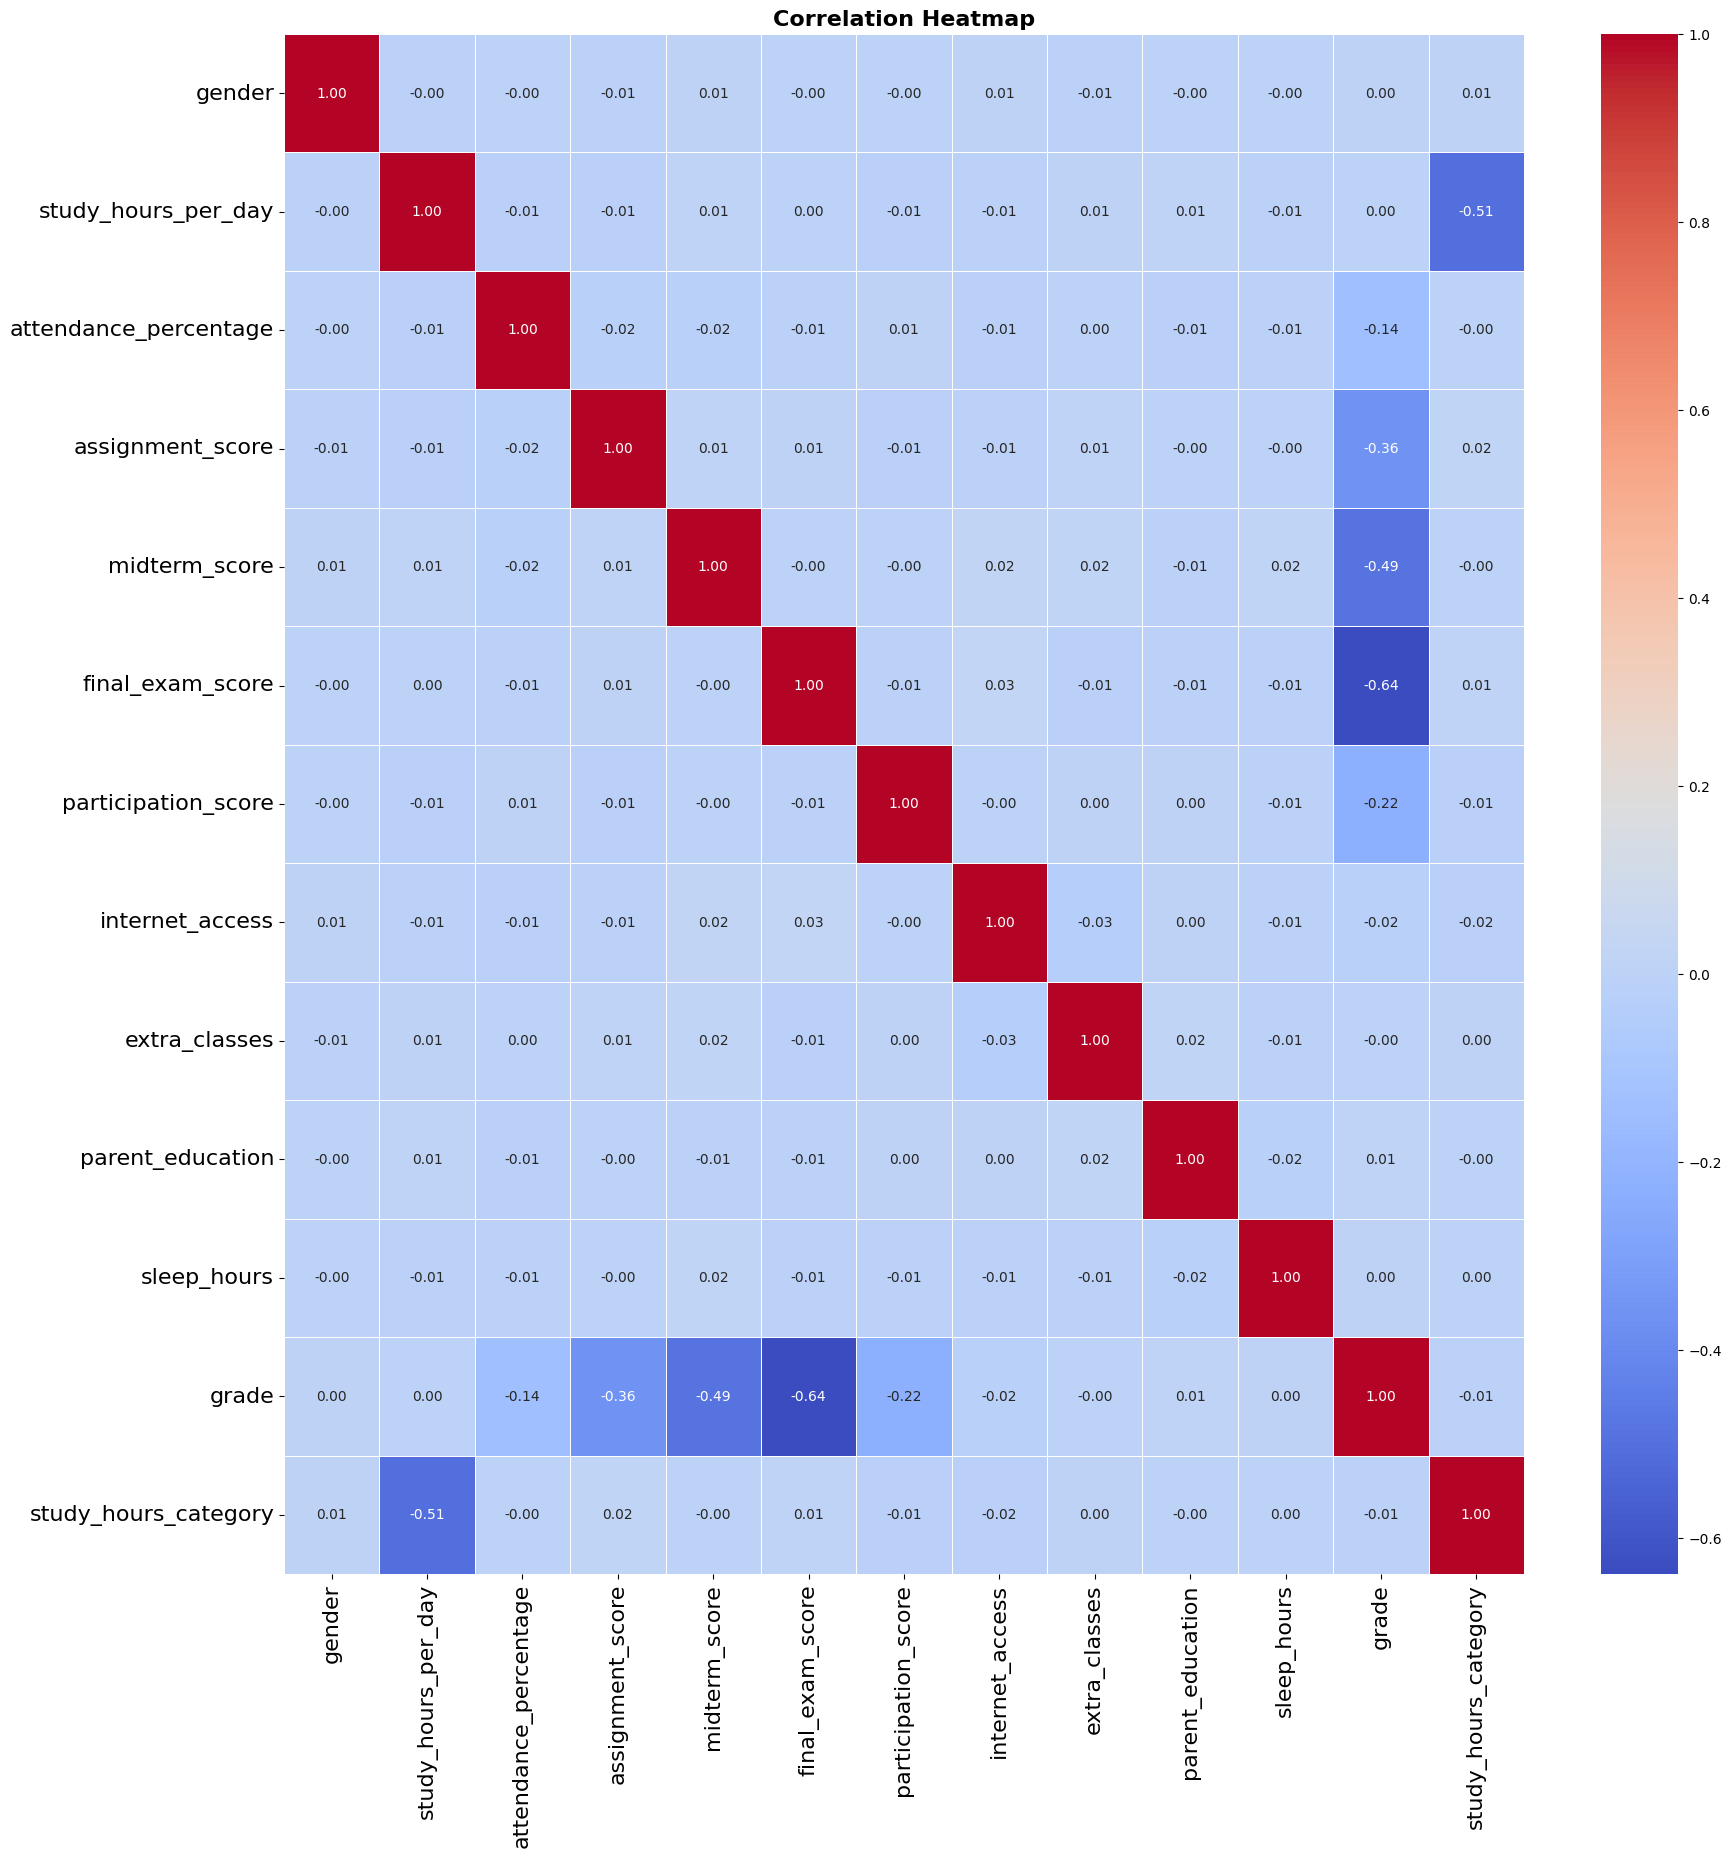

In [24]:
corr = df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.show()

### Data Split

In [25]:
# membuat data target 
X = df.drop(columns=['grade'])
Y = df['grade']

In [26]:
# membagi data menjadi data train dan data test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (8000, 12)
Testing : (2000, 12)


### Modeling

In [27]:
# Daftar model
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "Naive Bayes": GaussianNB()
}

# Standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan metrik untuk semua model
results = []

for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(Y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(Y_test, y_pred, average='weighted', zero_division=0)
    
    # Untuk ROC AUC, perlu prediksi probabilitas dan konversi ke bentuk binary jika multiclass
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_scaled)
            if y_proba.shape[1] == 2:
                roc = roc_auc_score(Y_test, y_proba[:, 1])
            else:
                roc = roc_auc_score(Y_test, y_proba, multi_class='ovr')
        else:
            roc = 0.0
    except:
        roc = 0.0
    
    results.append([name, acc, prec, rec, f1, roc])

# Buat DataFrame dari hasil evaluasi
columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC_AUC"]
results_df = pd.DataFrame(results, columns=columns)

# Tampilkan tabel hasil
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC_AUC
Logistic Regression    0.9870   0.987130  0.9870  0.985243 0.999512
     Decision Trees    0.8295   0.828912  0.8295  0.828822 0.792122
      Random Forest    0.8890   0.893436  0.8890  0.883706 0.989269
            XGBoost    0.9315   0.931633  0.9315  0.930508 0.995437
        Naive Bayes    0.8155   0.849978  0.8155  0.805545 0.971225


### Evaluasi

In [28]:
# Daftar model
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "Naive Bayes": GaussianNB()
}

# Standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan metrik untuk semua model
results = []

for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(Y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(Y_test, y_pred, average='weighted', zero_division=0)
    
    # Untuk ROC AUC, perlu prediksi probabilitas dan konversi ke bentuk binary jika multiclass
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_scaled)
            if y_proba.shape[1] == 2:
                roc = roc_auc_score(Y_test, y_proba[:, 1])
            else:
                roc = roc_auc_score(Y_test, y_proba, multi_class='ovr')
        else:
            roc = 0.0
    except:
        roc = 0.0
    
    results.append([name, acc, prec, rec, f1, roc])

# Buat DataFrame dari hasil evaluasi
columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC_AUC"]
results_df = pd.DataFrame(results, columns=columns)

# Tampilkan tabel hasil
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC_AUC
Logistic Regression    0.9870   0.987130  0.9870  0.985243 0.999512
     Decision Trees    0.8295   0.828912  0.8295  0.828822 0.792122
      Random Forest    0.8890   0.893436  0.8890  0.883706 0.989269
            XGBoost    0.9315   0.931633  0.9315  0.930508 0.995437
        Naive Bayes    0.8155   0.849978  0.8155  0.805545 0.971225


Classification Report model Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.62      0.55      0.58       548
           2       0.63      0.77      0.69      1007
           3       0.70      0.49      0.58       406
           4       0.00      0.00      0.00        12

    accuracy                           0.64      2000
   macro avg       0.39      0.36      0.37      2000
weighted avg       0.63      0.64      0.63      2000



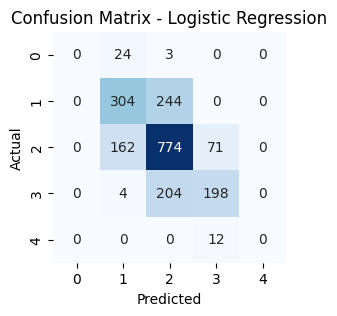

Classification Report model Decision Trees:
              precision    recall  f1-score   support

           0       0.46      0.48      0.47        27
           1       0.85      0.81      0.83       548
           2       0.84      0.87      0.86      1007
           3       0.81      0.78      0.80       406
           4       0.33      0.25      0.29        12

    accuracy                           0.83      2000
   macro avg       0.66      0.64      0.65      2000
weighted avg       0.83      0.83      0.83      2000



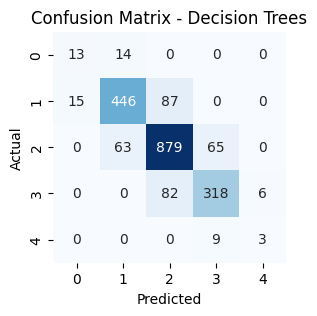

Classification Report model Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.26      0.41        27
           1       0.92      0.86      0.89       548
           2       0.87      0.96      0.91      1007
           3       0.92      0.82      0.87       406
           4       1.00      0.08      0.15        12

    accuracy                           0.89      2000
   macro avg       0.94      0.60      0.65      2000
weighted avg       0.89      0.89      0.88      2000



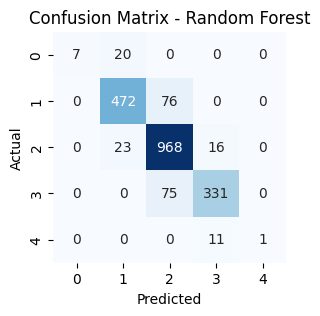

Classification Report model XGBoost:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        27
           1       0.93      0.94      0.93       548
           2       0.94      0.95      0.94      1007
           3       0.93      0.91      0.92       406
           4       1.00      0.33      0.50        12

    accuracy                           0.93      2000
   macro avg       0.92      0.77      0.81      2000
weighted avg       0.93      0.93      0.93      2000



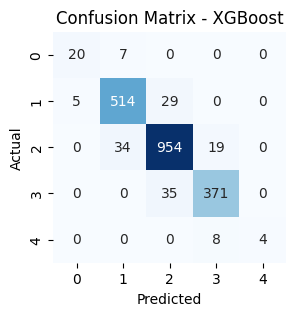

Classification Report model Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      0.44      0.62        27
           1       0.95      0.72      0.82       548
           2       0.75      0.99      0.85      1007
           3       0.95      0.54      0.69       406
           4       1.00      0.25      0.40        12

    accuracy                           0.82      2000
   macro avg       0.93      0.59      0.68      2000
weighted avg       0.85      0.82      0.81      2000



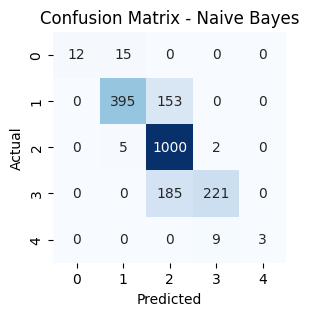

Model terbaik: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


In [29]:
best_model = None
best_accuracy = 0
for name, model in models.items():
    # Melakukan train setiap model
    model.fit(X_train, Y_train)

    # Melakukan prediksi model
    predict = model.predict(X_test)

    # Best Model
    accuracy = accuracy_score(Y_test, predict)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    # Classification Report
    print(f"Classification Report model {name}:")
    print(classification_report(Y_test, predict))

    # Confusion Matrix
    cm = confusion_matrix(Y_test, predict)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print(f"Model terbaik: {best_model}")

### Save Model

In [40]:
# Path folder model
model_dir = "../preprocessing/artifacts/models"

# Save semua model
for name, model in models.items():

    model_path = os.path.join(
        model_dir,
        f"{name.lower().replace(' ', '_')}.joblib"
    )

    joblib.dump(model, model_path)

    print(f"Model '{name}' berhasil disimpan di:")
    print(model_path)

# Save best model
best_model_path = os.path.join(
    model_dir,
    "best_model.joblib"
)

joblib.dump(best_model, best_model_path)

print("\nBest model berhasil disimpan:")
print(best_model_path)

Model 'logistic_regression' berhasil disimpan di:
../preprocessing/artifacts/models/logistic_regression.joblib
Model 'decision_tree' berhasil disimpan di:
../preprocessing/artifacts/models/decision_tree.joblib
Model 'random_forest' berhasil disimpan di:
../preprocessing/artifacts/models/random_forest.joblib
Model 'xgboost' berhasil disimpan di:
../preprocessing/artifacts/models/xgboost.joblib
Model 'naive_bayes' berhasil disimpan di:
../preprocessing/artifacts/models/naive_bayes.joblib

Best model berhasil disimpan:
../preprocessing/artifacts/models/best_model.joblib


In [42]:
joblib.dump(
    scaler,
    "../preprocessing/artifacts/encoders/scaler.joblib"
)

joblib.dump(
    label_encoders,
    "../preprocessing/artifacts/encoders/label_encoders.joblib"
)

['../preprocessing/artifacts/encoders/label_encoders.joblib']